In [1]:
# ------------------------------------------
# Import Required Libraries
# ------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (200, 8)


,moisture,force,temperature,accel_x,accel_y,accel_z,battery,label
0,89,91,37.69,0.39,-1.38,-1.38,94,Stool Detected
1,93,43,36.27,0.60,-1.77,0.89,49,Stool Detected
2,61,40,35.86,0.47,0.45,-1.97,68,Wet
3,96,79,36.42,-0.53,-0.18,1.14,70,Stool Detected
4,12,26,39.72,-1.32,-1.74,1.80,79,Abnormal Temperature


In [4]:
# ------------------------------------------
# Dataset Information
# ------------------------------------------

print("\nDataset Information")
print("-" * 50)

df.info()

print("\nStatistical Summary")
print("-" * 50)

print(df.describe())


Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   moisture     200 non-null    int64  
 1   force        200 non-null    int64  
 2   temperature  200 non-null    float64
 3   accel_x      200 non-null    float64
 4   accel_y      200 non-null    float64
 5   accel_z      200 non-null    float64
 6   battery      200 non-null    int64  
 7   label        200 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 12.6+ KB

Statistical Summary
--------------------------------------------------
       moisture       force  temperature     accel_x     accel_y     accel_z  \
count  200.0000  200.000000   200.000000  200.000000  200.000000  200.000000   
mean    49.2900   57.675000    37.137300    0.062500   -0.114350   -0.016600   
std     32.3903   22.566025  

In [5]:
# ------------------------------------------
# Check Missing Values
# ------------------------------------------

print("\nMissing Values")
print("-" * 50)

print(df.isnull().sum())


Missing Values
--------------------------------------------------
moisture       0
force          0
temperature    0
accel_x        0
accel_y        0
accel_z        0
battery        0
label          0
dtype: int64


In [6]:
# ------------------------------------------
# Remove Missing Values
# ------------------------------------------

df = df.dropna()

In [7]:
# ------------------------------------------
# Feature Selection
# ------------------------------------------

X = df.drop("label", axis=1)

y = df["label"]

print("\nFeatures Used")
print("-" * 50)

print(X.columns)


Features Used
--------------------------------------------------
Index(['moisture', 'force', 'temperature', 'accel_x', 'accel_y', 'accel_z',
       'battery'],
      dtype='object')


In [8]:
# ------------------------------------------
# Train Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# ------------------------------------------
# Feature Scaling
# ------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
# ------------------------------------------
# Train Random Forest Model
# ------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [11]:
# ------------------------------------------
# Predictions
# ------------------------------------------

y_pred = model.predict(X_test_scaled)

In [12]:
# ------------------------------------------
# Evaluation Metrics
# ------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nModel Performance")
print("-" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Model Performance
--------------------------------------------------
Accuracy  : 0.8000
Precision : 0.8000
Recall    : 0.8000
F1 Score  : 0.8000


In [13]:
# ------------------------------------------
# Classification Report
# ------------------------------------------

print("\nClassification Report")
print("-" * 50)

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report
--------------------------------------------------
                      precision    recall  f1-score   support

Abnormal Temperature       1.00      1.00      1.00        10
                 Dry       1.00      1.00      1.00        11
      Stool Detected       0.60      0.60      0.60        10
                 Wet       0.56      0.56      0.56         9

            accuracy                           0.80        40
           macro avg       0.79      0.79      0.79        40
        weighted avg       0.80      0.80      0.80        40



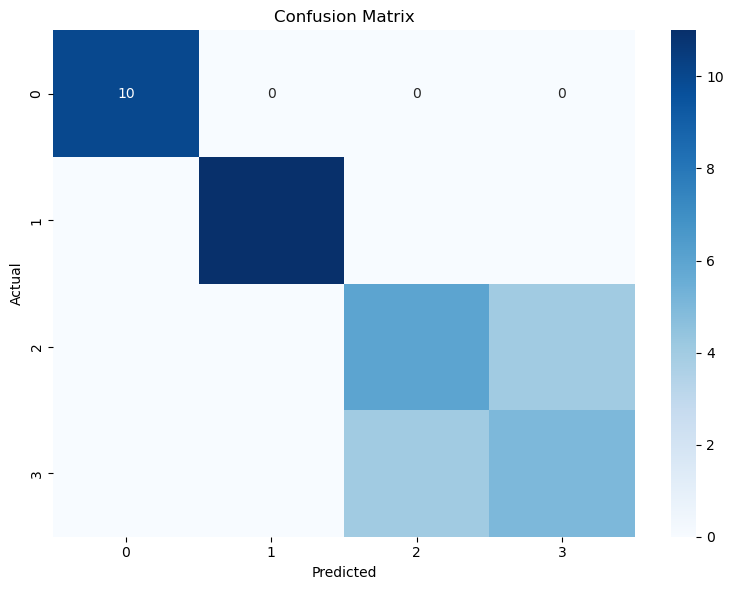

In [14]:
# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("evaluation_results.png")

plt.show()


Feature Importance
--------------------------------------------------
       Feature  Importance
0     moisture    0.389863
2  temperature    0.303685
1        force    0.070157
5      accel_z    0.067641
4      accel_y    0.062230
3      accel_x    0.057603
6      battery    0.048821


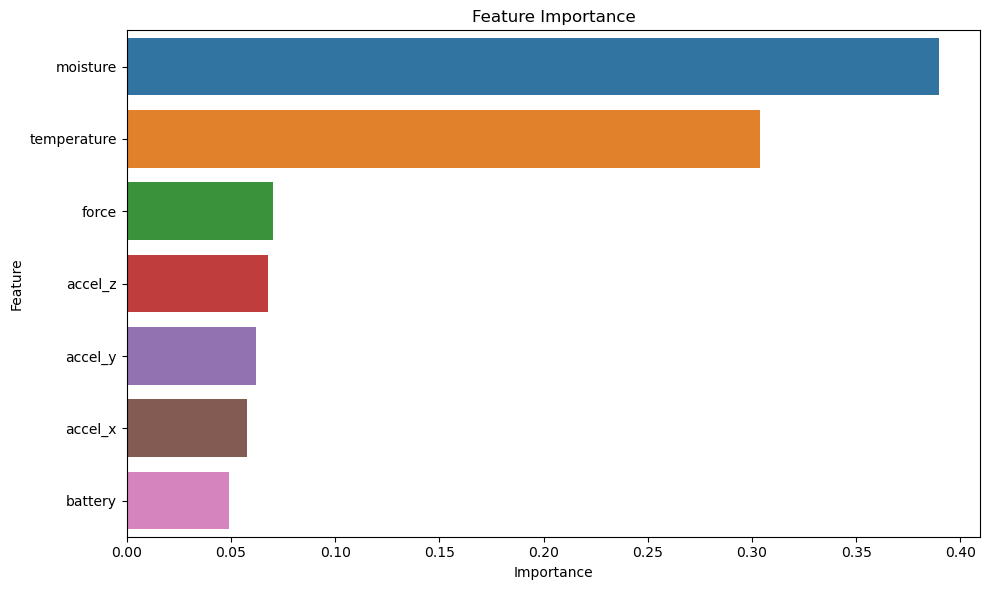

In [15]:
# ------------------------------------------
# Feature Importance
# ------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print("-" * 50)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [16]:
# ------------------------------------------
# Save Model
# ------------------------------------------

joblib.dump(
    model,
    "random_forest_model.pkl"
)

print("\nModel saved as random_forest_model.pkl")


Model saved as random_forest_model.pkl


In [17]:
# ------------------------------------------
# Save Scaler
# ------------------------------------------

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved as scaler.pkl")

# ------------------------------------------
# End
# ------------------------------------------

print("\nTraining Completed Successfully")

Scaler saved as scaler.pkl

Training Completed Successfully
